# Home Credit Default Risk — LR vs Random Forest vs XGBoost

Benchmarks three classical / boosted classifiers on the
[Home Credit Default Risk dataset](https://www.kaggle.com/c/home-credit-default-risk)
for predicting whether a client defaults on a loan.

For each algorithm we report performance with **default** and **Optuna-tuned**
hyperparameters.

| Model | Library | GPU |
| :--- | :--- | :--- |
| Logistic Regression | scikit-learn | No |
| Random Forest | scikit-learn | No |
| XGBoost | xgboost | Yes (tuning + final) |

Preprocessing, evaluation, and tracking logic live in the shared
[`src/`](../src) module so this notebook, the Lending Club baseline
notebook, and the FT-Transformer notebooks all run on **identical splits and
identical features**, and all write artifacts in a uniform layout.

**What gets saved.** After every model trains, `save_run_artifacts` writes:
- `{model}_perf.csv` — train/valid/test metrics
- `{model}_best_params.json` — tuned hyperparameters
- `{model}_study.csv` — full Optuna trial history
- `{model}_predictions_test.npy` — test-set scores (for cross-model comparisons later)
- appends a test-set row to `results/summary_test_metrics_home_credit.csv`

Plus per-dataset:
- `timings.csv` — wall-clock for default train, tuned train, tuning loop, inference
- `environment.json` — Python/library versions, GPU info, seed

> **Input data.** This notebook expects a single CSV
> (`home_credit_default.csv`) containing the joined application +
> supplementary aggregates produced by an upstream ETL notebook.

## 1. Setup

In [ ]:
# Install dependencies (uncomment on a fresh environment)
!pip install -q optuna xgboost shap scikit-learn pandas numpy joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.5 MB/s eta 0:00:00


In [ ]:
import os
import sys
import warnings

import numpy as np
import pandas as pd

# Make the shared src/ module importable when this notebook lives under notebooks/
sys.path.insert(0, os.path.abspath(".."))

from src.datasets import preprocess_home_credit
from src.preprocessing import preprocess_data_pipeline, seed_everything
from src.evaluation import report_performance
from src.interpretation import (
    get_shap_importance_xgb,
    get_shap_importance_rf,
    plot_shap_summary,
)
from src.tracking import (
    ExperimentLogger,
    time_block,
    capture_environment,
    save_run_artifacts,
    measure_inference_time,
    load_summary,
    load_timings,
)

import optuna
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import joblib

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.options.display.max_rows = 200
pd.options.display.max_columns = 200

RANDOM_SEED = 42
seed_everything(RANDOM_SEED)

### 1.1 Paths and tracking

In [ ]:
# --- Optional: Google Colab Drive mount ---
from google.colab import drive
drive.mount("/content/drive")
DRIVE_ROOT = "/content/drive/MyDrive/credit_risk_modeling"


Mounted at /content/drive


In [ ]:
_BASE = globals().get("DRIVE_ROOT", "..")
DATA_PATH      = f"{_BASE}/data/home_credit_default.csv"
ARTIFACTS_DIR  = f"{_BASE}/artifacts/home_credit"
RESULTS_DIR    = f"{_BASE}/results"

logger = ExperimentLogger(
    dataset="home_credit",
    artifacts_dir=ARTIFACTS_DIR,
    results_dir=RESULTS_DIR,
)
print(f"DATA_PATH      = {DATA_PATH}")
print(f"ARTIFACTS_DIR  = {ARTIFACTS_DIR}")
print(f"RESULTS_DIR    = {RESULTS_DIR}")

capture_environment(logger, seed=RANDOM_SEED);

DATA_PATH      = /content/drive/MyDrive/credit_risk_modeling/data/home_credit_default.csv
ARTIFACTS_DIR  = /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit
RESULTS_DIR    = /content/drive/MyDrive/credit_risk_modeling/results
  [env] captured -> /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/environment.json


## 2. Data Loading and Cleaning

`preprocess_home_credit` drops `XNA` gender rows, replaces the sentinel
365243 in `DAYS_*` columns with NaN, flips `DAYS_BIRTH` to a positive
age-in-days, and coerces all `FLAG*` columns to clean binary integers.

In [ ]:
df = pd.read_csv(DATA_PATH)
print(f"Raw shape: {df.shape}")

if "SK_ID_CURR" in df.columns:
    df = df.drop(columns=["SK_ID_CURR"])

df = preprocess_home_credit(df)
print(f"After domain cleaning: {df.shape}")
print()
print("Target distribution:")
print((df["TARGET"].value_counts(normalize=True) * 100).round(2).rename("pct"))

Raw shape: (307511, 381)
After domain cleaning: (307507, 380)

Target distribution:
TARGET
0    91.93
1     8.07
Name: pct, dtype: float64


## 3. Preprocessing Pipeline

In [ ]:
data = preprocess_data_pipeline(
    df, target="TARGET", corr_threshold=0.9, missing_threshold=0.9
)

X_train, X_valid, X_test = data.as_concatenated()
y_train, y_valid, y_test = data.y_train, data.y_valid, data.y_test

print("\nDataset Split Summary")
print("-" * 40)
print(f"Train : X = {X_train.shape},  y = {y_train.shape}")
print(f"Valid : X = {X_valid.shape},  y = {y_valid.shape}")
print(f"Test  : X = {X_test.shape},   y = {y_test.shape}")
print()
print(f"Numeric features    : {len(data.num_cols)}")
print(f"Categorical features: {len(data.cat_cols)}")

Step 1: Stratified split (64/16/20)
  Train=196,804 | Valid=49,201 | Test=61,502
Step 2: Missing-value column filter
  Threshold: 90% | Dropped 7 columns
Step 3: Correlation drop (numeric)


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  Numeric features before: 358 | Dropped: 66
Step 4: Median imputation (numeric)
Step 5: Label encoding (categorical)
Step 6: Standard scaling (numeric)

Final feature counts: numeric=292 | categorical=14 | total=306
Categorical cardinalities: [2, 2, 8, 8, 5, 5, 6, 19, 7, 58, 5, 4, 8, 3]

Dataset Split Summary
----------------------------------------
Train : X = (196804, 306),  y = (196804,)
Valid : X = (49201, 306),  y = (49201,)
Test  : X = (61502, 306),   y = (61502,)

Numeric features    : 292
Categorical features: 14


## 4. Logistic Regression

### 4.1 Default hyperparameters

In [ ]:
logreg_default = LogisticRegression()

with time_block("train", logger, model_name="lr_default"):
    logreg_default.fit(X_train, y_train)

perf_lr_default = report_performance(
    logreg_default, X_train, y_train, X_valid, y_valid, X_test, y_test
)

measure_inference_time(
    logreg_default, X_test, n_repeats=5,
    logger=logger, model_name="lr_default",
);

save_run_artifacts(
    logger,
    model_name="lr_default",
    perf_df=perf_lr_default,
    test_predictions=logreg_default.predict_proba(X_test)[:, 1],
    y_test=y_test.values,
)
perf_lr_default

  [timer] starting: lr_default/train
  [timer] lr_default/train: 18.74s (0.31 min)
  [inference] lr_default: median=17.98ms std=5.32ms (over 5 runs, 10000 samples)
  [save] lr_default: wrote 3 artifacts
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/lr_default_perf.csv
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/lr_default_predictions_test.npy
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/y_test.npy


,Segment,Total,Total Bad,Bad Rate,AUC,Gini,KS Statistic,AUCPR,Precision @10%,Recall @10% (Capture Rate)
Value,Train,196804,15888,0.0807,0.765513,0.531027,0.396806,0.244589,0.275443,0.341201
Value,Validation,49201,3972,0.0807,0.761075,0.522150,0.395035,0.241742,0.270677,0.335347
Value,Test,61502,4965,0.0807,0.762365,0.524730,0.396683,0.241728,0.272313,0.337362


### 4.2 Hyperparameter tuning with Optuna

In [ ]:
def tune_lr_objective(trial):
    C = trial.suggest_float("C", 1e-5, 100, log=True)
    penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
    use_balanced = trial.suggest_categorical("use_balanced", [True, False])
    class_weight = "balanced" if use_balanced else None

    model = LogisticRegression(
        C=C, penalty=penalty, solver="liblinear",
        class_weight=class_weight, random_state=RANDOM_SEED, max_iter=1000,
    )
    model.fit(X_train, y_train)
    val_preds = model.predict_proba(X_valid)[:, 1]
    return roc_auc_score(y_valid, val_preds)


N_TRIALS_LR = 20

study_lr = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    study_name="LR_HomeCredit_Tuning",
)

with time_block("tuning_loop", logger, model_name="lr_tuned"):
    study_lr.optimize(tune_lr_objective, n_trials=N_TRIALS_LR, show_progress_bar=True)

print(f"\nBest validation AUC: {study_lr.best_value:.5f}")
print("Best params:")
for k, v in study_lr.best_params.items():
    print(f"  {k}: {v}")

[I 2026-05-13 12:40:34,165] A new study created in memory with name: LR_HomeCredit_Tuning


  [timer] starting: lr_tuned/tuning_loop


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-13 12:41:34,636] Trial 0 finished with value: 0.7627100931620284 and parameters: {'C': 0.004185822729546971, 'penalty': 'l1', 'use_balanced': True}. Best is trial 0 with value: 0.7627100931620284.
[I 2026-05-13 12:41:47,845] Trial 1 finished with value: 0.7136849598564067 and parameters: {'C': 0.0001235838277230692, 'penalty': 'l2', 'use_balanced': False}. Best is trial 0 with value: 0.7627100931620284.
[I 2026-05-13 12:41:51,071] Trial 2 finished with value: 0.5253024654863111 and parameters: {'C': 1.3934502251337587e-05, 'penalty': 'l1', 'use_balanced': True}. Best is trial 0 with value: 0.7627100931620284.
[I 2026-05-13 12:42:13,271] Trial 3 finished with value: 0.7601939337595365 and parameters: {'C': 0.00019223460470643635, 'penalty': 'l2', 'use_balanced': True}. Best is trial 0 with value: 0.7627100931620284.
[I 2026-05-13 12:45:22,245] Trial 4 finished with value: 0.7635064323108829 and parameters: {'C': 0.19185373703841915, 'penalty': 'l2', 'use_balanced': False}. Be

### 4.3 Final logistic regression with tuned hyperparameters

In [ ]:
best_params_lr = study_lr.best_params

logreg = LogisticRegression(
    C=best_params_lr["C"],
    penalty=best_params_lr["penalty"],
    class_weight="balanced" if best_params_lr.get("use_balanced") else None,
    solver="liblinear",
    random_state=RANDOM_SEED,
    max_iter=1000,
)

with time_block("train", logger, model_name="lr_tuned"):
    logreg.fit(X_train, y_train)

perf_lr_tuned = report_performance(
    logreg, X_train, y_train, X_valid, y_valid, X_test, y_test
)

measure_inference_time(
    logreg, X_test, n_repeats=5,
    logger=logger, model_name="lr_tuned",
);

save_run_artifacts(
    logger,
    model_name="lr_tuned",
    perf_df=perf_lr_tuned,
    best_params=best_params_lr,
    study=study_lr,
    test_predictions=logreg.predict_proba(X_test)[:, 1],
    y_test=y_test.values,
)

joblib.dump(logreg, logger.artifact_path("logistic_regression.pkl"))
perf_lr_tuned

  [timer] starting: lr_tuned/train
  [timer] lr_tuned/train: 111.60s (1.86 min)
  [inference] lr_tuned: median=14.92ms std=0.22ms (over 5 runs, 10000 samples)
  [save] lr_tuned: wrote 4 artifacts
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/lr_tuned_perf.csv
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/lr_tuned_best_params.json
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/lr_tuned_study.csv
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/lr_tuned_predictions_test.npy


,Segment,Total,Total Bad,Bad Rate,AUC,Gini,KS Statistic,AUCPR,Precision @10%,Recall @10% (Capture Rate)
Value,Train,196804,15888,0.0807,0.768101,0.536201,0.401800,0.244349,0.276510,0.342523
Value,Validation,49201,3972,0.0807,0.763907,0.527814,0.399265,0.240690,0.273522,0.338872
Value,Test,61502,4965,0.0807,0.763267,0.526533,0.396435,0.242868,0.274752,0.340383


## 5. Random Forest

### 5.1 Default hyperparameters

In [ ]:
rf_default = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1)

with time_block("train", logger, model_name="rf_default"):
    rf_default.fit(X_train, y_train)

perf_rf_default = report_performance(
    rf_default, X_train, y_train, X_valid, y_valid, X_test, y_test
)

measure_inference_time(
    rf_default, X_test, n_repeats=5,
    logger=logger, model_name="rf_default",
);

save_run_artifacts(
    logger,
    model_name="rf_default",
    perf_df=perf_rf_default,
    test_predictions=rf_default.predict_proba(X_test)[:, 1],
    y_test=y_test.values,
)
perf_rf_default

  [timer] starting: rf_default/train
  [timer] rf_default/train: 219.28s (3.65 min)
  [inference] rf_default: median=734.62ms std=166.58ms (over 5 runs, 10000 samples)
  [save] rf_default: wrote 2 artifacts
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/rf_default_perf.csv
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/rf_default_predictions_test.npy


,Segment,Total,Total Bad,Bad Rate,AUC,Gini,KS Statistic,AUCPR,Precision @10%,Recall @10% (Capture Rate)
Value,Train,196804,15888,0.0807,1.000000,1.000000,1.000000,1.000000,0.802060,1.000000
Value,Validation,49201,3972,0.0807,0.722364,0.444728,0.327977,0.212097,0.246310,0.310926
Value,Test,61502,4965,0.0807,0.723839,0.447679,0.340281,0.214968,0.246644,0.318228


### 5.2 Hyperparameter tuning with Optuna

In [ ]:
def tune_rf_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 2000),
        "max_samples": trial.suggest_float("max_samples", 0.6, 0.9),
        "max_depth": trial.suggest_int("max_depth", 2, 5),
        "min_samples_split": trial.suggest_int("min_samples_split", 10, 100),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 15, 50),
        "max_features": trial.suggest_float("max_features", 0.6, 0.9),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
    }
    model = RandomForestClassifier(
        **params, class_weight="balanced_subsample",
        n_jobs=-1, random_state=RANDOM_SEED,
    )
    model.fit(X_train, y_train)
    val_pred = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, val_pred)
    print(f"Trial {trial.number} -> AUC: {auc:.5f}")
    return auc


N_TRIALS_RF = 10

study_rf = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    study_name="RF_HomeCredit_Tuning",
)

with time_block("
tuning_loop", logger, model_name="rf_tuned"):
    study_rf.optimize(tune_rf_objective, n_trials=N_TRIALS_RF, show_progress_bar=True)

print(f"\nBest validation AUC: {study_rf.best_value:.5f}")
print(f"Best params: {study_rf.best_params}")

[I 2026-05-14 06:36:54,830] A new study created in memory with name: RF_HomeCredit_Tuning


  [timer] starting: rf_tuned/tuning_loop


  0%|          | 0/10 [00:00<?, ?it/s]

Trial 0 -> AUC: 0.71885
[I 2026-05-14 07:30:08,815] Trial 0 finished with value: 0.7188525419830074 and parameters: {'n_estimators': 937, 'max_samples': 0.8852142919229748, 'max_depth': 4, 'min_samples_split': 64, 'min_samples_leaf': 20, 'max_features': 0.6467983561008608, 'criterion': 'entropy'}. Best is trial 0 with value: 0.7188525419830074.
Trial 1 -> AUC: 0.70550
[I 2026-05-14 08:06:24,579] Trial 1 finished with value: 0.7055025753802452 and parameters: {'n_estimators': 1322, 'max_samples': 0.8124217733388137, 'max_depth': 2, 'min_samples_split': 98, 'min_samples_leaf': 44, 'max_features': 0.6637017332034828, 'criterion': 'entropy'}. Best is trial 0 with value: 0.7188525419830074.
Trial 2 -> AUC: 0.71256
[I 2026-05-14 08:37:39,431] Trial 2 finished with value: 0.7125640137844346 and parameters: {'n_estimators': 817, 'max_samples': 0.7574269294896714, 'max_depth': 3, 'min_samples_split': 36, 'min_samples_leaf': 37, 'max_features': 0.6418481581956126, 'criterion': 'entropy'}. Best i

### 5.3 Final random forest with tuned hyperparameters

In [ ]:
best_params_rf = study_rf.best_params

rf = RandomForestClassifier(
    **best_params_rf,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=RANDOM_SEED,
)

with time_block("train", logger, model_name="rf_tuned"):
    rf.fit(X_train, y_train)

perf_rf_tuned = report_performance(
    rf, X_train, y_train, X_valid, y_valid, X_test, y_test
)

measure_inference_time(
    rf, X_test, n_repeats=5,
    logger=logger, model_name="rf_tuned",
);

save_run_artifacts(
    logger,
    model_name="rf_tuned",
    perf_df=perf_rf_tuned,
    best_params=best_params_rf,
    study=study_rf,
    test_predictions=rf.predict_proba(X_test)[:, 1],
    y_test=y_test.values,
)

joblib.dump(rf, logger.artifact_path("random_forest.pkl"))
perf_rf_tuned

  [timer] starting: rf_tuned/train
  [timer] rf_tuned/train: 1585.03s (26.42 min)
  [inference] rf_tuned: median=229.84ms std=15.33ms (over 5 runs, 10000 samples)
  [save] rf_tuned: wrote 4 artifacts
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/rf_tuned_perf.csv
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/rf_tuned_best_params.json
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/rf_tuned_study.csv
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/rf_tuned_predictions_test.npy


,Segment,Total,Total Bad,Bad Rate,AUC,Gini,KS Statistic,AUCPR,Precision @10%,Recall @10% (Capture Rate)
Value,Train,196804,15888,0.0807,0.735717,0.471435,0.346715,0.211788,0.242671,0.300604
Value,Validation,49201,3972,0.0807,0.725016,0.450031,0.329432,0.205149,0.234505,0.290534
Value,Test,61502,4965,0.0807,0.729130,0.458260,0.339465,0.210351,0.242237,0.300101


## 6. XGBoost (GPU)

### 6.1 Default hyperparameters

In [ ]:
EARLY_STOPPING_ROUNDS = 50

xgb_default_config = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "device": "cuda",
    "random_state": RANDOM_SEED,
    "n_jobs": -1,
    "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
}

model_xgb_default = xgb.XGBClassifier(**xgb_default_config)

with time_block("train", logger, model_name="xgb_default"):
    model_xgb_default.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_valid, y_valid)],
        verbose=100,
    )

perf_xgb_default = report_performance(
    model_xgb_default, X_train, y_train, X_valid, y_valid, X_test, y_test
)

measure_inference_time(
    model_xgb_default, X_test, n_repeats=5,
    logger=logger, model_name="xgb_default",
);

save_run_artifacts(
    logger,
    model_name="xgb_default",
    perf_df=perf_xgb_default,
    test_predictions=model_xgb_default.predict_proba(X_test)[:, 1],
    y_test=y_test.values,
)
perf_xgb_default

  [timer] starting: xgb_default/train
[0]	validation_0-auc:0.72191	validation_1-auc:0.70882
[86]	validation_0-auc:0.89231	validation_1-auc:0.76536
  [timer] xgb_default/train: 7.69s (0.13 min)
  [inference] xgb_default: median=78.55ms std=4.42ms (over 5 runs, 10000 samples)
  [save] xgb_default: wrote 2 artifacts
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/xgb_default_perf.csv
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/home_credit/xgb_default_predictions_test.npy


,Segment,Total,Total Bad,Bad Rate,AUC,Gini,KS Statistic,AUCPR,Precision @10%,Recall @10% (Capture Rate)
Value,Train,196804,15888,0.0807,0.840806,0.681612,0.518044,0.407664,0.378690,0.469096
Value,Validation,49201,3972,0.0807,0.768011,0.536022,0.405127,0.249105,0.279008,0.345670
Value,Test,61502,4965,0.0807,0.768087,0.536174,0.404768,0.257237,0.281093,0.348238


### 6.2 Hyperparameter tuning with Optuna

In [ ]:
def tune_xgb_objective(trial):
    neg_count = len(y_train) - y_train.sum()
    pos_count = y_train.sum()
    theoretical_ratio = neg_count / pos_count
    spw_min = theoretical_ratio * 0.5
    spw_max = theoretical_ratio * 2.0

    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "device": "cuda",
        "random_state": RANDOM_SEED,
        "n_jobs": -1,
        "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
        "n_estimators": trial.suggest_int("n_estimators", 300, 3000),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 4),
        "lambda": trial.suggest_float("lambda", 1.0, 5.0),
        "alpha": trial.suggest_float("alpha", 1.0, 5.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", spw_min, spw_max, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 10, 50),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
    }

    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
    val_preds = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, val_preds)
    print(f"Trial {trial.number} -> AUC: {auc:.5f}")
    return auc


N_TRIALS_XGB = 30

study_xgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    study_name="XGBoost_HomeCredit_Tuning",
)

with time_block("tuning_loop", logger, model_name="xgb_tuned"):
    study_xgb.optimize(tune_xgb_objective, n_trials=N_TRIALS_XGB, show_progress_bar=True)

print(f"\nBest validation AUC: {study_xgb.best_value:.5f}")
print("Best params:")
for k, v in study_xgb.best_params.items():
    print(f"  {k}: {v}")

[I 2026-05-14 12:50:08,165] A new study created in memory with name: XGBoost_HomeCredit_Tuning


  [timer] starting: xgb_tuned/tuning_loop


  0%|          | 0/30 [00:00<?, ?it/s]

Trial 0 -> AUC: 0.78234
[I 2026-05-14 12:50:20,130] Trial 0 finished with value: 0.7823449586758863 and parameters: {'n_estimators': 1311, 'learning_rate': 0.07114476009343425, 'max_depth': 4, 'lambda': 3.3946339367881464, 'alpha': 1.624074561769746, 'scale_pos_weight': 7.067988102679941, 'min_child_weight': 12, 'gamma': 0.08499808989182997, 'subsample': 0.8404460046972835, 'colsample_bytree': 0.8832290311184181}. Best is trial 0 with value: 0.7823449586758863.
Trial 1 -> AUC: 0.77920
[I 2026-05-14 12:50:29,288] Trial 1 finished with value: 0.779198076980839 and parameters: {'n_estimators': 355, 'learning_rate': 0.0812324508558869, 'max_depth': 4, 'lambda': 1.8493564427131046, 'alpha': 1.7272998688284025, 'scale_pos_weight': 7.34172761701465, 'min_child_weight': 22, 'gamma': 0.00015777981883364995, 'subsample': 0.7727780074568463, 'colsample_bytree': 0.7164916560792167}. Best is trial 0 with value: 0.7823449586758863.
Trial 2 -> AUC: 0.70664
[I 2026-05-14 12:50:39,009] Trial 2 finished

### 6.3 Final XGBoost with tuned hyperparameters

In [ ]:
best_params_xgb = study_xgb.best_params

xgb_final_config = {
    **best_params_xgb,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "device": "cuda",
    "random_state": RANDOM_SEED,
    "n_jobs": -1,
    "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
}

model_xgb = xgb.XGBClassifier(**xgb_final_config)

with time_block("train", logger, model_name="xgb_tuned"):
    model_xgb.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_valid, y_valid)],
        verbose=100,
    )

perf_xgb_tuned = report_performance(
    model_xgb, X_train, y_train, X_valid, y_valid, X_test, y_test
)

measure_inference_time(
    model_xgb, X_test, n_repeats=5,
    logger=logger, model_name="xgb_tuned",
);

save_run_artifacts(
    logger,
    model_name="xgb_tuned",
    perf_df=perf_xgb_tuned,
    best_params=best_params_xgb,
    study=study_xgb,
    test_predictions=model_xgb.predict_proba(X_test)[:, 1],
    y_test=y_test.values,
)

model_xgb.save_model(logger.artifact_path("xgb_model.json"))
perf_xgb_tuned

  [timer] starting: xgb_tuned/train
[0]	validation_0-auc:0.67947	validation_1-auc:0.67908
[100]	validation_0-auc:0.75574	validation_1-auc:0.74588
[200]	validation_0-auc:0.77491	validation_1-auc:0.76095
[300]	validation_0-auc:0.78604	validation_1-auc:0.76835
[400]	validation_0-auc:0.79373	validation_1-auc:0.77230
[500]	validation_0-auc:0.79969	validation_1-auc:0.77503
[600]	validation_0-auc:0.80495	validation_1-auc:0.77680
[700]	validation_0-auc:0.80978	validation_1-auc:0.77819
[800]	validation_0-auc:0.81409	validation_1-auc:0.77931
[900]	validation_0-auc:0.81832	validation_1-auc:0.78012
[1000]	validation_0-auc:0.82228	validation_1-auc:0.78080
[1100]	validation_0-auc:0.82596	validation_1-auc:0.78141
[1200]	validation_0-auc:0.82949	validation_1-auc:0.78177
[1300]	validation_0-auc:0.83285	validation_1-auc:0.78206
[1400]	validation_0-auc:0.83613	validation_1-auc:0.78242
[1500]	validation_0-auc:0.83936	validation_1-auc:0.78265
[1600]	validation_0-auc:0.84254	validation_1-auc:0.78283
[1700]	

,Segment,Total,Total Bad,Bad Rate,AUC,Gini,KS Statistic,AUCPR,Precision @10%,Recall @10% (Capture Rate)
Value,Train,196804,15888,0.0807,0.848993,0.697986,0.538925,0.365252,0.361465,0.447759
Value,Validation,49201,3972,0.0807,0.783440,0.566881,0.432824,0.273245,0.292420,0.362286
Value,Test,61502,4965,0.0807,0.781593,0.563186,0.423780,0.284842,0.300927,0.372810


## 7. SHAP Feature Importance

### 7.1 SHAP — XGBoost

In [ ]:
shap_xgb_df, shap_xgb_values = get_shap_importance_xgb(model_xgb, X_test)
shap_xgb_df.to_csv(logger.artifact_path("shap_importance_xgb.csv"), index=False)
shap_xgb_df.head(20)

,Feature,SHAP_Value_Contribution
0,EXT_SOURCE_2,0.342402
1,EXT_SOURCE_3,0.274039
2,EXT_SOURCE_1,0.138019
3,AMT_ANNUITY_x,0.132652
4,CODE_GENDER,0.120924
5,AMT_PAYMENT,0.115903
6,DAYS_EMPLOYED,0.109889
7,CNT_INSTALMENT_FUTURE,0.099126
8,CNT_PAYMENT,0.096067
9,AMT_GOODS_PRICE_x,0.089725


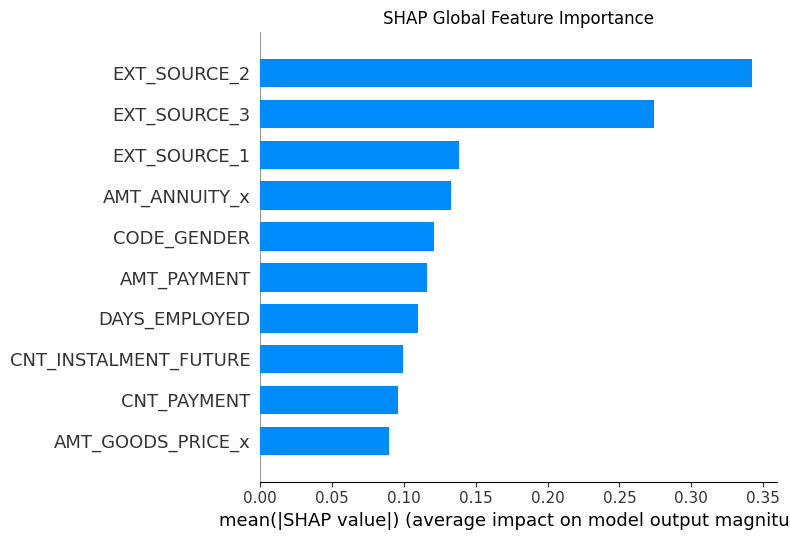

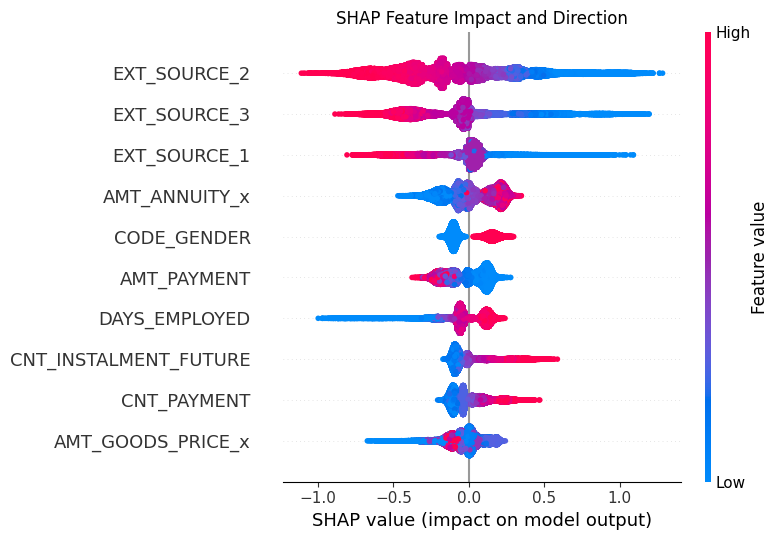

In [ ]:
plot_shap_summary(
    shap_xgb_values, X_test, max_features=10,
    save_prefix=logger.artifact_path("shap_xgb"),
)

### 7.2 SHAP — Random Forest

In [ ]:
rf = joblib.load(logger.artifact_path("random_forest.pkl"))

In [ ]:
shap_rf_df, shap_rf_values = get_shap_importance_rf(rf, X_test)
shap_rf_df.to_csv(logger.artifact_path("shap_importance_rf.csv"), index=False)
shap_rf_df.head(20)

,Feature,SHAP_Value_Contribution
0,EXT_SOURCE_2,0.090137
1,EXT_SOURCE_3,0.084249
2,EXT_SOURCE_1,0.023134
3,DAYS_EMPLOYED,0.013466
4,DAYS_BIRTH,0.005026
5,AMT_PAYMENT,0.004216
6,DAYS_CREDIT,0.003897
7,NAME_EDUCATION_TYPE,0.003272
8,NAME_CONTRACT_STATUS_Refused,0.002641
9,CREDIT_ACTIVE_Closed,0.002639


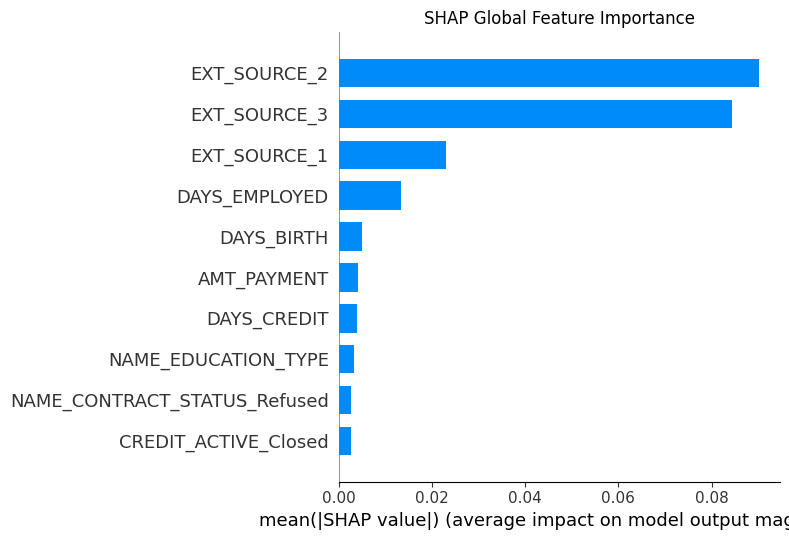

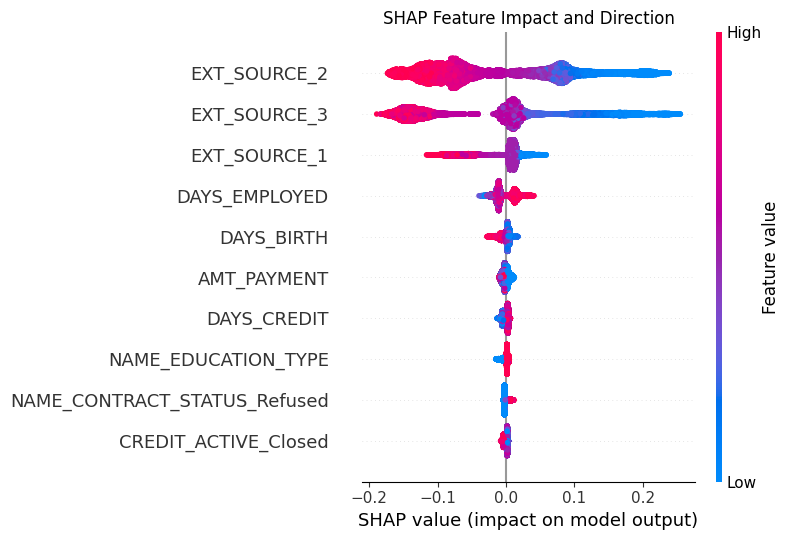

In [ ]:
plot_shap_summary(
    shap_rf_values, X_test, max_features=10,
    save_prefix=logger.artifact_path("shap_rf"),
)

## 8. Summary

`save_run_artifacts` already appended each model's test-set row to
`results/summary_test_metrics_home_credit.csv` as we trained.

In [ ]:
summary = load_summary(RESULTS_DIR, "home_credit")
summary[[
    "model_name", "AUC", "Gini", "KS_Statistic", "AUCPR",
    "Precision_top10", "Recall_top10",
]]

,model_name,AUC,Gini,KS_Statistic,AUCPR,Precision_top10,Recall_top10
0,lr_default,0.762365,0.524730,0.396683,0.241728,0.272313,0.337362
1,lr_tuned,0.763267,0.526533,0.396435,0.242868,0.274752,0.340383
2,rf_default,0.723839,0.447679,0.340281,0.214968,0.246644,0.318228
3,rf_tuned,0.729130,0.458260,0.339465,0.210351,0.242237,0.300101
4,xgb_default,0.768087,0.536174,0.404768,0.257237,0.281093,0.348238
5,xgb_tuned,0.781593,0.563186,0.423780,0.284842,0.300927,0.372810


### Timings table (Experiment 2.3 source data)

In [ ]:
timings = load_timings(ARTIFACTS_DIR)
timings_pivot = (
    timings
    .pivot_table(index="model_name", columns="block", values="seconds", aggfunc="last")
    .round(3)
)
timings_pivot

block,inference_10000,train,tuning_loop
model_name,,,
lr_default,0.018,18.738,NaN
lr_tuned,0.015,111.598,5649.355
rf_default,0.735,219.281,NaN
rf_tuned,0.230,1585.033,20073.091
xgb_default,0.079,7.686,NaN
xgb_tuned,0.103,25.558,494.800
